In [1]:
import sys
sys.path.insert(0, '..')
from typing import Callable

import altair as alt
import polars as pl

from IPython.display import display, HTML
from diaphanous.nibrs import configure, load_all
import diaphanous.bka as bka
from diaphanous.chart import plot_age_distribution

def html(markup: str) -> None:
    display(HTML(markup))

def hn(level: int) -> Callable[[str], None]:
    if not 1 <= level <= 6:
        raise ValueError(f"invalid heading level {level}")
    def h(title: str) -> None:
        html(f"<h{level}>{title}</h{level}>")
    return h

h1 = hn(1)
h2 = hn(2)
h3 = hn(3)

import rpy2
%load_ext rpy2.ipython
import diaphanous.arr as arr
#arr.enable_write_hook()
arr.install()
RLIB = arr.RLIB

Error importing in API mode: ImportError("dlopen(/Users/rgrimm/Work/diaphanous/.venv/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): symbol not found in flat namespace '_R_BaseEnv'")
Trying to import in ABI mode.


In [2]:
h1("Overview")

configure()
us = load_all()
de = bka.Data.ingest()

display(us.caseload_table())
display(de.caseload_table())
display(us.severity_table())
display(de.severity_table())
display(us.completion_table())

offenders = us.offender_demographics().age_distribution()
suspects = de.age_distribution()

fig = alt.vconcat(
    plot_age_distribution(offenders, "Offenders", "US"),
    plot_age_distribution(suspects, "Suspects", "Germany"),
).resolve_scale(x="shared")

fig.save("../figure/age-distributions.svg")
fig

GT(_tbl_data=shape: (3, 4)
┌───────────┬────────────┬─────────┬────────────┐
│ Variant   ┆ Count 2023 ┆ ∆% 2024 ┆ Count 2024 │
│ ---       ┆        --- ┆     --- ┆        --- │
│ str       ┆        u32 ┆     f64 ┆        u32 │
╞═══════════╪════════════╪═════════╪════════════╡
│ Offenders ┆     16,565 ┆     0.1 ┆     18,038 │
│ Incidents ┆     15,199 ┆     0.1 ┆     16,500 │
│ Arrestees ┆      2,703 ┆     0.2 ┆      3,280 │
└───────────┴────────────┴─────────┴────────────┘, _body=<great_tables._gt_data.Body object at 0x1278457f0>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='Count 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='∆% 2024', type=<ColInfoTypeEnum.default: 1>, column_label='∆%', column_align='right', column_width=None), ColInfo(var='Count 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1274f2990>, _spanners=Spanners([SpannerInfo(spanner_id='2023', spanner_level=0, spanner_label='2023', spanner_units=None, spanner_pattern=None, vars=['Count 2023'], built=None), SpannerInfo(spanner_id='2024', spanner_level=0, spanner_label='2024', spanner_units=None, spanner_pattern=None, vars=['∆% 2024', 'Count 2024'], built=None)]), _heading=Heading(title='CSAM Caseload (US)', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x127845be0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x127845550>, <great_tables._gt_data.FormatInfo object at 0x1274f2490>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x1274f2d50>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', v

GT(_tbl_data=shape: (2, 4)
┌───────────┬────────────┬─────────┬────────────┐
│ Variant   ┆ Count 2023 ┆ ∆% 2024 ┆ Count 2024 │
│ ---       ┆        --- ┆     --- ┆        --- │
│ str       ┆        i64 ┆     f64 ┆        i64 │
╞═══════════╪════════════╪═════════╪════════════╡
│ Incidents ┆     54,042 ┆    -0.0 ┆     52,455 │
│ Suspects  ┆     45,494 ┆    -0.0 ┆     44,188 │
└───────────┴────────────┴─────────┴────────────┘, _body=<great_tables._gt_data.Body object at 0x127457e10>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='Count 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='∆% 2024', type=<ColInfoTypeEnum.default: 1>, column_label='∆%', column_align='right', column_width=None), ColInfo(var='Count 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x127457490>, _spanners=Spanners([SpannerInfo(spanner_id='2023', spanner_level=0, spanner_label='2023', spanner_units=None, spanner_pattern=None, vars=['Count 2023'], built=None), SpannerInfo(spanner_id='2024', spanner_level=0, spanner_label='2024', spanner_units=None, spanner_pattern=None, vars=['∆% 2024', 'Count 2024'], built=None)]), _heading=Heading(title='CSAM Caseload (Germany)', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1274f2c10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x127457bb0>, <great_tables._gt_data.FormatInfo object at 0x12787c3e0>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x1274ae0f0>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, ca

GT(_tbl_data=shape: (3, 5)
┌─────────┬────────────┬──────────────┬────────────┬──────────────┐
│ Variant ┆ Count 2023 ┆ Percent 2023 ┆ Count 2024 ┆ Percent 2024 │
│ ---     ┆        --- ┆          --- ┆        --- ┆          --- │
│ str     ┆        u32 ┆          f64 ┆        u32 ┆          f64 │
╞═════════╪════════════╪══════════════╪════════════╪══════════════╡
│ Supply  ┆      1,190 ┆          0.1 ┆      1,260 ┆          0.1 │
│ Demand  ┆     14,009 ┆          0.9 ┆     15,240 ┆          0.9 │
│ 🖩 Total ┆     15,199 ┆          1.0 ┆     16,500 ┆          1.0 │
└─────────┴────────────┴──────────────┴────────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x127835260>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='Count 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='Percent 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Percent', column_align='right', column_width=None), ColInfo(var='Count 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='Percent 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Percent', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1274ae0f0>, _spanners=Spanners([SpannerInfo(spanner_id='2023', spanner_level=0, spanner_label='2023', spanner_units=None, spanner_pattern=None, vars=['Count 2023', 'Percent 2023'], built=None), SpannerInfo(spanner_id='2024', spanner_level=0, spanner_label='2024', spanner_units=None, spanner_pattern=None, vars=['Count 2024', 'Percent 2024'], built=None)]), _heading=Heading(title='Offense Severity (US)', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x1274f2ad0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1278346b0>, <great_tables._gt_data.FormatInfo object at 0x127835480>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x127856050>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', 

GT(_tbl_data=shape: (3, 5)
┌─────────┬────────────┬──────────────┬────────────┬──────────────┐
│ Variant ┆ Count 2023 ┆ Percent 2023 ┆ Count 2024 ┆ Percent 2024 │
│ ---     ┆        --- ┆          --- ┆        --- ┆          --- │
│ str     ┆        i64 ┆          f64 ┆        i64 ┆          f64 │
╞═════════╪════════════╪══════════════╪════════════╪══════════════╡
│ Supply  ┆     33,029 ┆          0.6 ┆     33,073 ┆          0.6 │
│ Demand  ┆     21,013 ┆          0.4 ┆     19,382 ┆          0.4 │
│ 🖩 Total ┆     54,042 ┆          1.0 ┆     52,455 ┆          1.0 │
└─────────┴────────────┴──────────────┴────────────┴──────────────┘, _body=<great_tables._gt_data.Body object at 0x112c84050>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='Count 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='Percent 2023', type=<ColInfoTypeEnum.default: 1>, column_label='Percent', column_align='right', column_width=None), ColInfo(var='Count 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Count', column_align='right', column_width=None), ColInfo(var='Percent 2024', type=<ColInfoTypeEnum.default: 1>, column_label='Percent', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x1278349e0>, _spanners=Spanners([SpannerInfo(spanner_id='2023', spanner_level=0, spanner_label='2023', spanner_units=None, spanner_pattern=None, vars=['Count 2023', 'Percent 2023'], built=None), SpannerInfo(spanner_id='2024', spanner_level=0, spanner_label='2024', spanner_units=None, spanner_pattern=None, vars=['Count 2024', 'Percent 2024'], built=None)]), _heading=Heading(title='Offense Severity (Germany)', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x127457950>, _formats=[<great_tables._gt_data.FormatInfo object at 0x127854f50>, <great_tables._gt_data.FormatInfo object at 0x12748af30>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x12748b020>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='s

GT(_tbl_data=shape: (2, 3)
┌───────────┬────────┬────────┐
│ Variant   ┆   2023 ┆   2024 │
│ ---       ┆    --- ┆    --- │
│ str       ┆    u32 ┆    u32 │
╞═══════════╪════════╪════════╡
│ Attempted ┆    557 ┆    607 │
│ Completed ┆ 14,642 ┆ 15,893 │
└───────────┴────────┴────────┘, _body=<great_tables._gt_data.Body object at 0x12782a270>, _boxhead=Boxhead([ColInfo(var='Variant', type=<ColInfoTypeEnum.stub: 2>, column_label='Variant', column_align='left', column_width=None), ColInfo(var='2023', type=<ColInfoTypeEnum.default: 1>, column_label='2023', column_align='right', column_width=None), ColInfo(var='2024', type=<ColInfoTypeEnum.default: 1>, column_label='2024', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x127855050>, _spanners=Spanners([]), _heading=Heading(title='Offense Completion', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x127457bb0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x1278299b0>, <great_tables._gt_data.FormatInfo object at 0x12782a970>], _substitutions=[<great_tables._gt_data.FormatInfo object at 0x1274e2ea0>], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Bahnschrift', 'DIN Alternate', 'Franklin Gothic Medium', 'Nimbus Sans Narrow', 'sans-serif-condensed', 'sans-serif', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji', 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_lef

alt.VConcatChart(...)

In [9]:
len(us.offenses.select(pl.col("incident_id").unique())), len(us.offenses)

(31699, 31699)

In [3]:
%%R -i RLIB

.libPaths(RLIB)
library(tidyverse)

nibrs <- read.csv("../data/nibrs/offenders.csv")
nibrs <- nibrs |>
  mutate(
    Group = factor(Group, levels = c("Child", "Adolescent", "Adult")),
    Sex = factor(Sex, levels = c("Female", "Male")),
    Race = factor(Race, levels = c("White", "Black", "Hispanic", "Other"))
  )

nibrs.24 <- nibrs |> filter(Year == 2024)
nibrs.24.contab <- xtabs(Count ~ Group + Race + Sex, data = nibrs.24)

library(vcdExtra)
vcd::mosaic(
  ~ Group + Race + Sex, data = nibrs.24.contab, direction = c("v", "h", "v"),
  shade = TRUE,
  main = "Offenders by Age Group, Race, and Sex",
  rot_labels = c(0, 0, 45, 0),
  offset_labels = c(0, 0, -0.5, -0.5),
  just_labels = c("center", "left", "right", "right"),
  offset_varnames = c(0.2, 0, 0.2, 0.2),
  margins = c(3, 0.3, 3, 4)
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Error in `mutate()`:
ℹ In argument: `Group = factor(Group, levels = c("Child", "Adolescent",
  "Adult"))`.
Caused by error:
! object 'Group' not found
Run `rlang::last_trace()` to see where the error occurred.

Error in mutate(nibrs, Group = factor(Group, levels = c("Child", "Adolescent",  : 
  
Caused by error:
! object 'Group' not found


RInterpreterError: Failed to parse and evaluate line '\n.libPaths(RLIB)\nlibrary(tidyverse)\n\nnibrs <- read.csv("../data/nibrs/offenders.csv")\nnibrs <- nibrs |>\n  mutate(\n    Group = factor(Group, levels = c("Child", "Adolescent", "Adult")),\n    Sex = factor(Sex, levels = c("Female", "Male")),\n    Race = factor(Race, levels = c("White", "Black", "Hispanic", "Other"))\n  )\n\nnibrs.24 <- nibrs |> filter(Year == 2024)\nnibrs.24.contab <- xtabs(Count ~ Group + Race + Sex, data = nibrs.24)\n\nlibrary(vcdExtra)\nvcd::mosaic(\n  ~ Group + Race + Sex, data = nibrs.24.contab, direction = c("v", "h", "v"),\n  shade = TRUE,\n  main = "Offenders by Age Group, Race, and Sex",\n  rot_labels = c(0, 0, 45, 0),\n  offset_labels = c(0, 0, -0.5, -0.5),\n  just_labels = c("center", "left", "right", "right"),\n  offset_varnames = c(0.2, 0, 0.2, 0.2),\n  margins = c(3, 0.3, 3, 4)\n)\n'.
R error message: 'Error in mutate(nibrs, Group = factor(Group, levels = c("Child", "Adolescent",  : \n  \nCaused by

Rows: 12 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Group, Sex
dbl (2): Year, Count

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


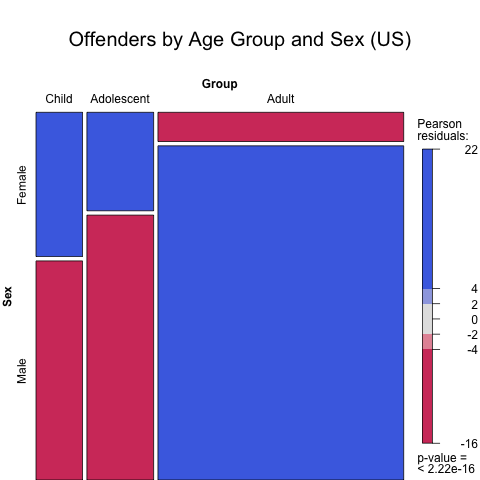

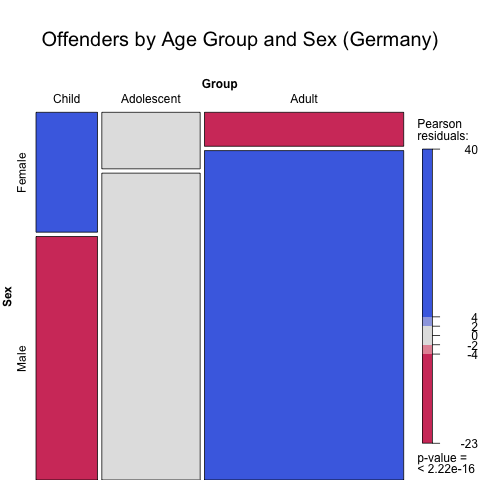

In [ ]:
%%R -i RLIB

nibrs.24.age.sex <- xtabs(Count ~ Group + Sex, data = nibrs.24)

vcd::mosaic(
  ~ Group + Sex,
  data = nibrs.24.age.sex,
  direction = c("v", "h"),
  shade = TRUE,
  margins = c(2.5, 0.3, 0, 2.5),
  main = "Offenders by Age Group and Sex (US)",
)

bka.24 <- read_csv("../data/bka/suspects.csv") |>
  mutate(
    Group = factor(Group, levels = c("Child", "Adolescent", "Adult")),
    Sex = factor(Sex, levels = c("Female", "Male")),
  ) |>
  filter(Year == 2024)
bka.24.age.sex <- xtabs(Count ~ Group + Sex, data = bka.24)

vcd::mosaic(
  ~ Group + Sex,
  data = bka.24.age.sex,
  direction = c("v", "h"),
  shade = TRUE,
  margins = c(2.5, 0.3, 0, 2.5),
  main = "Offenders by Age Group and Sex (Germany)"
)

In [ ]:
# h1("Attribute Impact on Offender Age Groups")

# for year, data in yearly.items():
#     h2(f"{year}")
#     arrestees = data.arrestee_demographics()
#     offenders = data.offender_demographics()

#     DISTRIBUTIONS = (
#         arrestees.age_distribution(grouped=False),
#         offenders.variant_distribution("Female"),
#         offenders.variant_distribution("Male"),
#         offenders.variant_distribution("Black"),
#         offenders.variant_distribution("White"),
#         offenders.location_distribution("In Cyberspace", Location.CYBERSPACE),
#         offenders.location_distribution(
#             "At School",
#             Location.SCHOOL_ELEMENTARY_SECONDARY,
#             Location.SCHOOL_COLLEGE,
#         ),
#         offenders.location_distribution("At Home", Location.RESIDENCE_HOME),
#         offenders.using_distribution(
#             "With Computer", Using.COMPUTER_EQUIPMENT_HANDHELD_DEVICES
#         ),
#         offenders.clearance_distribution("Juvenile", Clearance.JUVENILE),
#     )

#     display(offenders.chart_counts())

#     for label, overlay in DISTRIBUTIONS:
#         display(offenders.chart_counts(label, overlay))

In [ ]:
# h1("Attribute / Offender Ratio")

# for year, data in yearly.items():
#     h2(f"{year}")
#     offenders = data.offender_demographics()

#     display(offenders.chart_ratios(*DISTRIBUTIONS[:5]))
#     display(offenders.chart_ratios(*DISTRIBUTIONS[5:]))

#     h3("Using Three-Year Rolling Average for Smoothing")

#     display(offenders.chart_ratios(*DISTRIBUTIONS[:5], smooth=True))
#     display(offenders.chart_ratios(*DISTRIBUTIONS[5:], smooth=True))